# Notebook 02 — Self-Attention, by Hand

*No training. No model class. Just the mechanism, derived from first principles, with every intermediate matrix visible.*

## What we're doing and why

Bigram failed because it couldn't use context. The fix: at every position `t`, build a hidden state that **mixes information from earlier positions** (0, 1, ..., t-1, and t itself). That mixing operation is *attention*.

This notebook **does not train anything**. We will:

1. Use a tiny synthetic example (`B=1, T=4, C=2`) we can read by eye.
2. Build the dumbest possible mixer — "average all past tokens" — and see why it's insufficient.
3. Discover the matrix-form trick that makes averaging fast.
4. Generalize: instead of *uniform* weights, use **content-dependent** weights.
5. Derive where those weights come from: **Q · Kᵀ**.
6. Add **softmax** to turn raw affinities into probabilities.
7. Add the **causal mask** so position `t` cannot peek at the future.
8. Apply weights to **V** (not the raw input) — and explain *why* values are a separate projection.
9. Derive the **√d_k scaling** with a variance argument.
10. Wrap it into a clean `Head` class (ready for notebook 03).
11. Visualize attention weights on a real Shakespeare batch with random-init Q/K/V (so you see the *shape* of attention before training gives it meaning).

By the end of this notebook you should be able to compute attention with pen and paper on a 3-token sequence. That's the goal.


## Cell 1 — Setup and a toy sequence

We'll work on a single batch of 4 tokens, each represented as a 2-dimensional vector. Small enough to print and reason about.

- `B` (batch) = 1
- `T` (time/sequence length) = 4
- `C` (channels/embedding dim) = 2

Think of `x` below as the output of a token embedding layer: 4 tokens, each turned into a 2D vector. Don't worry about the specific numbers — they're chosen to be readable, not meaningful.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(1337)

B, T, C = 1, 4, 2
x = torch.tensor([[
    [1.0,  0.0],   # token 0
    [0.0,  1.0],   # token 1
    [1.0,  1.0],   # token 2
    [-1.0, 0.5],   # token 3
]])
print('x shape:', tuple(x.shape))
print(x)


x shape: (1, 4, 2)
tensor([[[ 1.0000,  0.0000],
         [ 0.0000,  1.0000],
         [ 1.0000,  1.0000],
         [-1.0000,  0.5000]]])


## Cell 2 — The dumbest mixer: average all past tokens

Goal: at position `t`, produce a hidden state `h_t` that summarizes positions `0..t`.

Dumbest possible recipe: just average them.

$$h_t = \frac{1}{t+1} \sum_{s=0}^{t} x_s$$

So `h_0 = x_0`, `h_1 = (x_0 + x_1)/2`, `h_2 = (x_0 + x_1 + x_2)/3`, etc.

Let's do it the obvious way first — an explicit Python loop. This is **NOT how you implement attention**, but it's how you should *think* about it the first time.


In [2]:
# Naive loop version
h_loop = torch.zeros_like(x)
for b in range(B):
    for t in range(T):
        h_loop[b, t] = x[b, :t+1].mean(dim=0)

print('input x:')
print(x[0])
print('\nh = running average of x:')
print(h_loop[0])
print('\nNotice: h_0 = x_0, h_1 = (x_0 + x_1)/2, etc. Each h_t mixes its own past.')


input x:
tensor([[ 1.0000,  0.0000],
        [ 0.0000,  1.0000],
        [ 1.0000,  1.0000],
        [-1.0000,  0.5000]])

h = running average of x:
tensor([[1.0000, 0.0000],
        [0.5000, 0.5000],
        [0.6667, 0.6667],
        [0.2500, 0.6250]])

Notice: h_0 = x_0, h_1 = (x_0 + x_1)/2, etc. Each h_t mixes its own past.


## Cell 3 — The same thing, in matrix form (the key insight)

Loops are slow. We want to compute *all* the `h_t`s in one matrix multiply. The trick:

Define a **weight matrix** `W` of shape `(T, T)` where row `t` holds the weights used to build `h_t`. For the running average:

```
W = [[1,    0,    0,    0   ],     # h_0 = 1·x_0
     [1/2,  1/2,  0,    0   ],     # h_1 = (1/2)·x_0 + (1/2)·x_1
     [1/3,  1/3,  1/3,  0   ],     # h_2 = (1/3)·x_0 + (1/3)·x_1 + (1/3)·x_2
     [1/4,  1/4,  1/4,  1/4 ]]     # h_3 = (1/4)·(...)
```

Then **`h = W @ x`** computes all running averages at once.

### Why this matters

Once you see this matrix form, you realize: *any* way of mixing past tokens can be written as `W @ x`, just with different `W`. The **only** thing that varies between different attention mechanisms is **how you compute `W`**.

- Uniform average: `W` is the row-normalized lower-triangular ones matrix (what we have).
- Self-attention: `W = softmax(Q @ Kᵀ / √d_k)` with causal mask.

Same matrix multiply. Different way of producing `W`.

### Building `W` the lazy way

Start with `tril(ones)` (lower-triangular ones), then row-normalize so each row sums to 1.


In [3]:
# Lower-triangular ones
tril = torch.tril(torch.ones(T, T))
print('lower-triangular ones (the causal mask, in mask form):')
print(tril)

# Row-normalize so each row sums to 1
W = tril / tril.sum(dim=1, keepdim=True)
print('\nrow-normalized W (uniform-average weights):')
print(W)

# Apply: h = W @ x. Same answer as the loop, in one mul.
h_matmul = W @ x
print('\nh = W @ x:')
print(h_matmul[0])

print('\nmatches loop version?', torch.allclose(h_matmul, h_loop))


lower-triangular ones (the causal mask, in mask form):
tensor([[1., 0., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 1.]])

row-normalized W (uniform-average weights):
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500]])

h = W @ x:
tensor([[1.0000, 0.0000],
        [0.5000, 0.5000],
        [0.6667, 0.6667],
        [0.2500, 0.6250]])

matches loop version? True


## Cell 4 — Doing the row-normalize via softmax (sets us up for the real thing)

There's a *second* way to build that same uniform `W`: start with **zeros** on the lower triangle, **-∞** on the upper triangle, then **softmax each row**.

Why this works: `softmax([0, 0, ..., 0, -∞, -∞, ..., -∞])` becomes `[1/k, 1/k, ..., 1/k, 0, 0, ..., 0]` for the `k` non-`-∞` entries. Exactly the same as row-normalizing the ones matrix.

Why we care: in real attention, the lower-triangle won't all be zeros — it'll be *learned affinity scores*. Softmax then turns those scores into a valid probability distribution per row. We're warming up the machinery.

### The causal mask, in code form

```python
scores = torch.zeros(T, T)
scores = scores.masked_fill(tril == 0, float('-inf'))
W = F.softmax(scores, dim=-1)
```


In [4]:
scores = torch.zeros(T, T)
scores = scores.masked_fill(tril == 0, float('-inf'))
print('scores (0 on lower triangle, -inf on upper):')
print(scores)

W_softmax = F.softmax(scores, dim=-1)
print('\nW via softmax (should equal the row-normalized version):')
print(W_softmax)

print('\nidentical?', torch.allclose(W, W_softmax))


scores (0 on lower triangle, -inf on upper):
tensor([[0., -inf, -inf, -inf],
        [0., 0., -inf, -inf],
        [0., 0., 0., -inf],
        [0., 0., 0., 0.]])

W via softmax (should equal the row-normalized version):
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500]])

identical? True


## Cell 5 — Generalizing: arbitrary (not just uniform) weights

Right now every past token gets equal weight. That's obviously dumb — in English, "the" should attend more to the *noun* it precedes than to the random punctuation 3 tokens back. Different past tokens should get different weights, **based on content**.

To do this, we replace the zeros in `scores` with arbitrary numbers (which we'll call **affinities**), then softmax + apply.

Example: hand-set scores that say "token 3 cares strongly about token 1, somewhat about token 2, ignores token 0."


In [5]:
# Hand-crafted affinity scores (not learned — just for demonstration)
scores = torch.tensor([
    [ 0.0, -float('inf'), -float('inf'), -float('inf')],
    [ 0.0,  0.0,          -float('inf'), -float('inf')],
    [ 0.0,  0.0,           0.0,          -float('inf')],
    [-2.0,  3.0,           1.0,           0.0         ],   # row 3: strong on tok 1, weak on tok 0
])
W = F.softmax(scores, dim=-1)
print('attention weights (each row is a probability distribution):')
print(W)
print('\nrow sums (should all be 1.0):', W.sum(dim=-1))

h = W @ x
print('\nh = W @ x:')
print(h[0])
print('\nnotice h_3 is dominated by x_1, exactly as the high score for column 1 predicted.')


attention weights (each row is a probability distribution):
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000],
        [0.0057, 0.8390, 0.1135, 0.0418]])

row sums (should all be 1.0): tensor([1.0000, 1.0000, 1.0000, 1.0000])

h = W @ x:
tensor([[1.0000, 0.0000],
        [0.5000, 0.5000],
        [0.6667, 0.6667],
        [0.0774, 0.9735]])

notice h_3 is dominated by x_1, exactly as the high score for column 1 predicted.


## Cell 6 — Where do affinity scores come from? Q · Kᵀ

We can't hand-craft scores for every sequence. We need a *function* that produces them from the tokens themselves. Here's the trick that makes transformers work:

### Every token plays three roles

For each token vector `x_t` (of dim C), we project it through **three different learnable matrices** to get three different views of the same token:

| Projection | Symbol | Meaning |
|---|---|---|
| Query | `q_t = W_Q · x_t` | "What am I looking for?" |
| Key   | `k_t = W_K · x_t` | "What do I offer / advertise?" |
| Value | `v_t = W_V · x_t` | "What do I actually pass along if attended to?" |

### Affinity is dot product

How much should token `i` attend to token `j`? Take **dot product** of `q_i` and `k_j`:

$$\text{score}_{ij} = q_i \cdot k_j = q_i^\top k_j$$

High dot product = `i`'s query aligns with `j`'s key = `i` should pay attention to `j`.

### Why dot product?

Dot product is the simplest way to measure "alignment" between two vectors. It rewards pointing in the same direction in high-dimensional space. Training will shape `W_Q` and `W_K` so that *queries and keys for related tokens end up pointing similar directions*. That's the entire learning signal of attention.

### Matrix form

Project all tokens at once:
- `Q = X @ W_Q` → shape `(T, head_size)`
- `K = X @ W_K` → shape `(T, head_size)`
- Scores = `Q @ Kᵀ` → shape `(T, T)`. Entry `(i,j)` = `q_i · k_j`. 

That's the affinity matrix. We've replaced hand-set numbers with a *learnable* function of the input.

Note: `head_size` doesn't have to equal `C`. It's a free hyperparameter — the dimensionality of the query/key space. We'll use `head_size = 4` here just to have it visibly distinct from `C=2`.


In [6]:
head_size = 4

# Random projection matrices (NOT trained — we'll train these in nb03)
W_Q = torch.randn(C, head_size) * 0.5
W_K = torch.randn(C, head_size) * 0.5
W_V = torch.randn(C, head_size) * 0.5

# Project all tokens at once
Q = x @ W_Q   # (B, T, head_size)
K = x @ W_K
V = x @ W_V

print('Q:'); print(Q[0])
print('K:'); print(K[0])

# Affinity scores: Q @ K^T → (B, T, T)
# K.transpose(-2, -1) swaps the last two dims so we get (B, head_size, T) for the matmul
scores = Q @ K.transpose(-2, -1)
print('\nraw scores (Q @ K^T) — note: not yet masked, not yet scaled, not yet softmaxed:')
print(scores[0])


Q:
tensor([[-1.0130, -1.0328, -0.6027, -0.4561],
        [-0.6251,  0.4016, -0.1036,  0.0272],
        [-1.6381, -0.6311, -0.7062, -0.4289],
        [ 0.7004,  1.2336,  0.5509,  0.4697]])
K:
tensor([[ 0.0689, -0.1945,  0.2567,  0.1660],
        [ 0.3150,  0.2907, -0.0141, -0.0872],
        [ 0.3839,  0.0963,  0.2426,  0.0788],
        [ 0.0886,  0.3398, -0.2637, -0.2096]])

raw scores (Q @ K^T) — note: not yet masked, not yet scaled, not yet softmaxed:
tensor([[-0.0994, -0.5711, -0.6705, -0.1862],
        [-0.1432, -0.0811, -0.2243,  0.1027],
        [-0.2426, -0.6522, -0.8948, -0.0835],
        [ 0.0277,  0.5306,  0.5583,  0.2375]])


## Cell 7 — Scale by √d_k, then mask, then softmax

Three things still missing before we have proper attention.

### (a) The √d_k scaling

Why divide scores by `√head_size`?

**Variance argument:** if `q` and `k` are independent random vectors with mean 0 and variance 1 in each component, then `q · k = Σᵢ qᵢ kᵢ` is a sum of `head_size` independent products. Each product has variance 1, so the dot product has variance `head_size`, hence standard deviation `√head_size`.

At larger `head_size`, scores get **bigger in magnitude**. Big scores into softmax produce **very peaky** distributions (one token gets ~1.0, others ~0). Peaky distributions have **tiny gradients** for the non-selected tokens, which kills learning.

Dividing by `√head_size` keeps scores at roughly unit variance regardless of `head_size`, so softmax stays usefully soft and gradients flow to everyone.

This is THE original "Attention Is All You Need" trick — scaled dot-product attention is just dot-product attention with this `1/√d_k` normalization.

### (b) The causal mask

At training time, token `t` predicts token `t+1`. If we let `q_t` attend to `k_{t+1}`, we're letting the model peek at the answer. Cheating.

Fix: before softmax, set all scores `(i, j)` with `j > i` to `-∞`. After softmax those weights become 0 — no leakage.

(For *inference* — generating one token at a time — you don't strictly need the mask because there *are* no future tokens yet. But we always include it during training, and we keep the code path the same for inference for simplicity.)

### (c) Softmax each row

Same as before — turns each row of affinities into a probability distribution over past tokens.


In [7]:
# (a) Scale
scaled = scores / (head_size ** 0.5)
print('scaled (= scores / sqrt(head_size)):'); print(scaled[0])

# (b) Causal mask
tril = torch.tril(torch.ones(T, T))
masked = scaled.masked_fill(tril == 0, float('-inf'))
print('\nmasked (upper triangle = -inf):'); print(masked[0])

# (c) Softmax each row
W_attn = F.softmax(masked, dim=-1)
print('\nattention weights (each row sums to 1, no future leakage):')
print(W_attn[0])


scaled (= scores / sqrt(head_size)):
tensor([[-0.0497, -0.2855, -0.3352, -0.0931],
        [-0.0716, -0.0405, -0.1122,  0.0514],
        [-0.1213, -0.3261, -0.4474, -0.0417],
        [ 0.0139,  0.2653,  0.2792,  0.1188]])

masked (upper triangle = -inf):
tensor([[-0.0497,    -inf,    -inf,    -inf],
        [-0.0716, -0.0405,    -inf,    -inf],
        [-0.1213, -0.3261, -0.4474,    -inf],
        [ 0.0139,  0.2653,  0.2792,  0.1188]])

attention weights (each row sums to 1, no future leakage):
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.4922, 0.5078, 0.0000, 0.0000],
        [0.3942, 0.3212, 0.2845, 0.0000],
        [0.2128, 0.2736, 0.2774, 0.2363]])


## Cell 8 — Apply weights to V (not x!) — and why

You might think the final step is `output = W_attn @ x`. After all, we already have the weights. Why introduce yet another projection `V`?

### The reason: separation of "what's interesting" from "what gets passed"

`q` and `k` decide **who talks to whom**.
`v` decides **what they say** when they talk.

These are different jobs. Consider: token 7 might want to *attend* to token 3 because they share a topic (q/k alignment), but the **information** it wants from token 3 might be very different from token 3's raw embedding — maybe just one feature, or a transformed version.

By projecting `x` to `v` through a *separate* learnable matrix, the model can decouple "is this token relevant?" (Q/K) from "what part of this token should I copy if it is relevant?" (V).

If we used `W_attn @ x` directly, every attention pattern would force the *full embedding* to be copied. With `V`, the model can selectively pull out features.

### The shape

`output = W_attn @ V` → `(T, T) @ (T, head_size)` → `(T, head_size)`.

Note the output dim is `head_size`, **not** `C`. In a multi-head setup we'll have several heads of `head_size = C / num_heads` each, then concatenate. For now `head_size = 4` ≠ `C = 2`; in nb04 we'll wire it so dims work out.


In [8]:
out = W_attn @ V
print('attention output, shape', tuple(out.shape), '(B, T, head_size)')
print(out[0])
print('\nrow t of the output is the attention-weighted mix of value vectors v_0..v_t.')


attention output, shape (1, 4, 4) (B, T, head_size)
tensor([[-0.6111,  0.7893,  0.2699,  0.5817],
        [-0.1244,  0.0761,  0.3073,  0.5870],
        [-0.2044,  0.1630,  0.3913,  0.7535],
        [ 0.0773, -0.2114,  0.2984,  0.5438]])

row t of the output is the attention-weighted mix of value vectors v_0..v_t.


## Cell 9 — Wrap it as a clean `Head` class

All the pieces in one place. This is essentially the class we'll train in notebook 03.

```python
class Head(nn.Module):
    def __init__(self, embed_dim, head_size, block_size):
        super().__init__()
        self.key   = nn.Linear(embed_dim, head_size, bias=False)
        self.query = nn.Linear(embed_dim, head_size, bias=False)
        self.value = nn.Linear(embed_dim, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.head_size = head_size

    def forward(self, x):
        # x: (B, T, embed_dim)
        B, T, _ = x.shape
        k = self.key(x)     # (B, T, head_size)
        q = self.query(x)   # (B, T, head_size)
        v = self.value(x)   # (B, T, head_size)

        scores = q @ k.transpose(-2, -1) / (self.head_size ** 0.5)   # (B, T, T)
        scores = scores.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        weights = F.softmax(scores, dim=-1)
        return weights @ v   # (B, T, head_size)
```

A few notes:

- `nn.Linear(C, head_size, bias=False)` is exactly `x @ W_Q` — Linear without bias is just a matrix multiply by a learnable weight.
- `register_buffer` stores the mask as model state (moves with `.to(device)`) but **not** a parameter (no gradients, not in `.parameters()`).
- `self.tril[:T, :T]` slices to the actual sequence length, so the same head handles any sequence ≤ `block_size`.


In [9]:
class Head(nn.Module):
    def __init__(self, embed_dim, head_size, block_size):
        super().__init__()
        self.key   = nn.Linear(embed_dim, head_size, bias=False)
        self.query = nn.Linear(embed_dim, head_size, bias=False)
        self.value = nn.Linear(embed_dim, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.head_size = head_size

    def forward(self, x):
        B, T, _ = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)
        scores = q @ k.transpose(-2, -1) / (self.head_size ** 0.5)
        scores = scores.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        weights = F.softmax(scores, dim=-1)
        return weights @ v, weights   # return weights too, for visualization

# Sanity test on our toy x
head = Head(embed_dim=C, head_size=head_size, block_size=T)
out, weights = head(x)
print('out shape:    ', tuple(out.shape))
print('weights shape:', tuple(weights.shape))
print('\nattention weights (one row per query position):')
print(weights[0])


out shape:     (1, 4, 4)
weights shape: (1, 4, 4)

attention weights (one row per query position):
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.5450, 0.4550, 0.0000, 0.0000],
        [0.3324, 0.4102, 0.2573, 0.0000],
        [0.3336, 0.2062, 0.3313, 0.1288]], grad_fn=<SelectBackward0>)


## Cell 10 — Visualize attention on real Shakespeare (untrained)

Now let's run our `Head` on an actual batch from Tiny Shakespeare. Two things to keep in mind:

1. **The model is untrained** — Q/K/V matrices are random. The attention pattern will be *random-looking*, not semantic. We're checking the *shape* and *plumbing*, not the meaning.

2. **What you should see:**
   - A lower-triangular heatmap (upper triangle = 0, because of the causal mask).
   - Roughly uniform-ish weights on each row (because randomly initialized Q,K dot products are near zero → softmax is near uniform).
   - In nb03, once trained, this pattern will become *structured* — diagonal stripes, vertical lines on important tokens, etc.

This is the "hello world" of attention: confirming it runs, the shapes are right, the mask works.


In [10]:
# Reproduce notebook 01's tokenizer (minimal) so this notebook stands alone.
from collections import Counter
from pathlib import Path

text = Path('../data/tinyshakespeare.txt').read_text().lower()
VOCAB_SIZE = 32
BLOCK_SIZE = 16

top = [c for c,_ in Counter(text).most_common(VOCAB_SIZE - 1)]
itos = ['<unk>'] + top
stoi = {c:i for i,c in enumerate(itos)}
encode = lambda s: [stoi.get(c, 0) for c in s]
decode = lambda ids: ''.join(itos[i] for i in ids)

# Grab one sequence of 16 tokens
data = torch.tensor(encode(text), dtype=torch.long)
start = 1000
seq = data[start : start + BLOCK_SIZE]
print('sequence:', repr(decode(seq.tolist())))

# Embed it (random embeddings, not trained — same situation as Q,K,V)
EMBED_DIM = 8
embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM)
x_real = embedding(seq).unsqueeze(0)   # (1, 16, 8)

# Run a head on it
head = Head(embed_dim=EMBED_DIM, head_size=8, block_size=BLOCK_SIZE)
out, weights = head(x_real)
print('out shape:    ', tuple(out.shape))
print('weights shape:', tuple(weights.shape))


sequence: 'second citi<unk>en:\n'
out shape:     (1, 16, 8)
weights shape: (1, 16, 16)


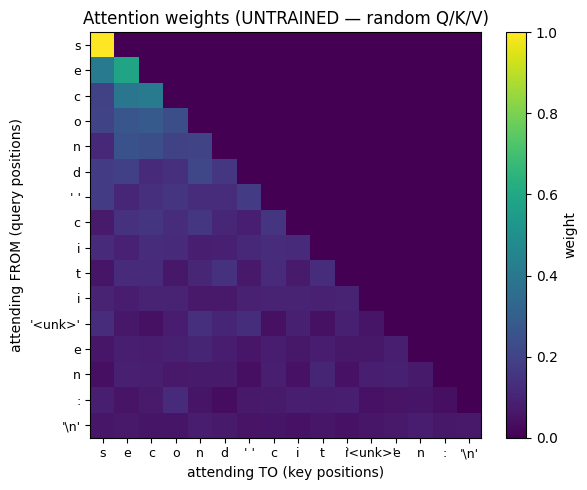


Observe:
  - Upper triangle is dark (zero) — causal mask working.
  - Lower triangle is roughly uniform within each row — random Q,K → roughly equal affinity.
  - In nb03 (trained), expect to see vertical stripes or diagonals — STRUCTURE.


In [11]:
# Visualize the attention weights as a heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(weights[0].detach(), cmap='viridis', aspect='auto')

# Label axes with the actual characters
labels = [repr(itos[i]) if itos[i] in (' ', '\n', '<unk>') else itos[i] for i in seq.tolist()]
ax.set_xticks(range(BLOCK_SIZE)); ax.set_xticklabels(labels, fontsize=9)
ax.set_yticks(range(BLOCK_SIZE)); ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('attending TO (key positions)')
ax.set_ylabel('attending FROM (query positions)')
ax.set_title('Attention weights (UNTRAINED — random Q/K/V)')
plt.colorbar(im, ax=ax, label='weight')
plt.tight_layout()
plt.show()

print('\nObserve:')
print('  - Upper triangle is dark (zero) — causal mask working.')
print('  - Lower triangle is roughly uniform within each row — random Q,K → roughly equal affinity.')
print('  - In nb03 (trained), expect to see vertical stripes or diagonals — STRUCTURE.')


## Post-mortem — what just happened

### The whole mechanism in one paragraph

For each token, project to **query** (what I want), **key** (what I offer), **value** (what I pass). Compute pairwise affinities as `Q @ Kᵀ`. Scale by `1/√d_k` to keep variance sane. Mask out the future with `-∞`. Softmax each row to get a probability distribution over past tokens. Use those probabilities to weight-average the **value** vectors. The result is a new per-token representation that has been informed by attention-weighted context.

### What's still missing (the rest of the transformer)

What we just built is **one attention head**, exactly the thing inside one transformer block. A full block adds:

- **Multiple heads** in parallel, then concatenated (`nb04`). Different heads can learn different patterns — one for syntax, one for semantics, etc.
- A **feed-forward MLP** after attention. Attention mixes across positions; the MLP mixes across the channel dimension at each position independently. Both kinds of mixing matter.
- **Residual connections** around both attention and MLP (`nb05`). Without these, deep networks can't train.
- **LayerNorm** before each sublayer (`nb05`). Stabilizes the magnitude of activations.

And around the block: token embeddings (we used these), **positional embeddings** (because attention is permutation-invariant — without positional info, the model can't tell `"the cat"` from `"cat the"`), and a final unembedding to logits.

### Why we did this without training

The mechanism — Q, K, V, scaled dot-product, mask, softmax, weighted V — is **architecture**, not a learned thing. The *projections* (`W_Q`, `W_K`, `W_V`) get trained, but the wiring around them is fixed. Most people first encounter attention as "this code from a paper that magically learns things," which makes it feel mysterious. Doing it untrained on toy data demystifies it: it's just six lines of tensor algebra, fully deterministic given the projections.

Notebook 03 plugs this Head into a real model and trains it on Tiny Shakespeare. We'll see the attention pattern go from random to structured, and we'll see the loss drop below the bigram baseline (2.44).

Onwards.
